In [1]:
import os
import math
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import kagglehub
mengcius_cinic10_path = kagglehub.dataset_download('mengcius/cinic10')

print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
from google.colab import drive
drive.mount('/content/drive')
from sklearn.metrics import f1_score


Using Colab cache for faster access to the 'cinic10' dataset.
Torch version: 2.10.0+cu128
CUDA available: True
Mounted at /content/drive


## Configuration

In [2]:
CFG = {
    'data_root': mengcius_cinic10_path,

    'shots': [5, 10, 20],
    'seeds': [42, 123, 2024, 7, 999],

    'epochs': 26,
    'batch_size': 128,
    'num_workers': 4,
    'lr': 0.01,
    'weight_decay': 0,

    'dropout': 0,
    'pretrained_source': 'imagenet',
    'custom_pretrained_ckpt': None,
    'freeze_backbone': False,

    'image_size': 32,

    'output_dir': './drive/MyDrive/fewshot_pretrained_outputs_lr001_bs128_flip_only/backbone_not_frozen_2',

    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

DEVICE = torch.device(CFG['device'])
Path(CFG['output_dir']).mkdir(parents=True, exist_ok=True)
print('DEVICE =', DEVICE)
print('pretrained_source =', CFG['pretrained_source'])
print('freeze_backbone =', CFG['freeze_backbone'])
print('batch_size =', CFG['batch_size'])
print('lr =', CFG['lr'])
print('weight_decay =', CFG['weight_decay'])
print('dropout =', CFG['dropout'])


DEVICE = cuda
pretrained_source = imagenet
freeze_backbone = False
batch_size = 128
lr = 0.01
weight_decay = 0
dropout = 0


## Reproducibility

In [3]:

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)


## Transforms

In [4]:
cinic_mean_RGB = [0.47889522, 0.47227842, 0.43047404]
cinic_std_RGB  = [0.24205776, 0.23828046, 0.25874835]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cinic_mean_RGB, cinic_std_RGB),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cinic_mean_RGB, cinic_std_RGB),
])


## Dataset i few-shot subset

In [5]:

def build_datasets(root: str):
    train_set = datasets.ImageFolder(os.path.join(root, 'train'), transform=train_transform)
    valid_set = datasets.ImageFolder(os.path.join(root, 'valid'), transform=eval_transform)
    test_set = datasets.ImageFolder(os.path.join(root, 'test'), transform=eval_transform)
    return train_set, valid_set, test_set


def make_k_shot_subset(dataset, k_per_class: int, seed: int = 42):
    rng = np.random.default_rng(seed)

    if not hasattr(dataset, 'targets'):
        raise AttributeError('Dataset musi mieć atrybut .targets (np. ImageFolder).')

    targets = np.array(dataset.targets)
    classes = np.unique(targets)
    selected_indices = []
    per_class_counts = {}

    for cls_id in classes:
        cls_indices = np.where(targets == cls_id)[0]
        if len(cls_indices) < k_per_class:
            raise ValueError(
                f'Klasa {cls_id} ma tylko {len(cls_indices)} próbek, a prosisz o {k_per_class}.'
            )
        chosen = rng.choice(cls_indices, size=k_per_class, replace=False)
        selected_indices.extend(chosen.tolist())
        per_class_counts[int(cls_id)] = len(chosen)

    selected_indices = sorted(selected_indices)
    subset = Subset(dataset, selected_indices)
    subset.indices_by_class = per_class_counts
    return subset


def build_loaders(root: str, k_shot: int, seed: int, batch_size: int, num_workers: int):
    train_set, valid_set, test_set = build_datasets(root)
    train_subset = make_k_shot_subset(train_set, k_per_class=k_shot, seed=seed)

    train_loader = DataLoader(
        train_subset,
        batch_size=min(batch_size, len(train_subset)),
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    valid_loader = DataLoader(
        valid_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    return train_set, valid_set, test_set, train_subset, train_loader, valid_loader, test_loader


In [6]:
train_set, valid_set, test_set = build_datasets(CFG['data_root'])
CLASS_NAMES = train_set.classes
NUM_CLASSES = len(CLASS_NAMES)

print('Liczba klas:', NUM_CLASSES)
print('Klasy:', CLASS_NAMES)
print('Train:', len(train_set), 'Valid:', len(valid_set), 'Test:', len(test_set))


Liczba klas: 10
Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 90000 Valid: 90000 Test: 90000


In [7]:

def show_fewshot_distribution(root: str, k_shot: int, seed: int):
    train_set, _, _ = build_datasets(root)
    subset = make_k_shot_subset(train_set, k_per_class=k_shot, seed=seed)
    counts = defaultdict(int)
    for idx in subset.indices:
        _, y = train_set.samples[idx]
        counts[train_set.classes[y]] += 1
    return pd.DataFrame({
        'class_name': list(counts.keys()),
        'count': list(counts.values())
    }).sort_values('class_name').reset_index(drop=True)

show_fewshot_distribution(CFG['data_root'], k_shot=CFG['shots'][0], seed=CFG['seeds'][0])


,class_name,count
0,airplane,5
1,automobile,5
2,bird,5
3,cat,5
4,deer,5
5,dog,5
6,frog,5
7,horse,5
8,ship,5
9,truck,5


## Model pretrained / custom init

In [8]:
from torchvision.models import MobileNet_V2_Weights

def get_mobilenetv2_pretrained(num_classes: int, dropout_rate: float = 0.0, pretrained_source: str = 'imagenet'):
    if pretrained_source == 'imagenet':
        model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    elif pretrained_source in ['custom', 'none']:
        model = models.mobilenet_v2(weights=None)
    else:
        raise ValueError("pretrained_source musi być jednym z: 'imagenet', 'custom', 'none'")

    old_conv = model.features[0][0]
    model.features[0][0] = nn.Conv2d(
        in_channels=old_conv.in_channels,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=1,
        padding=old_conv.padding,
        dilation=old_conv.dilation,
        groups=old_conv.groups,
        bias=(old_conv.bias is not None),
    )

    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(model.classifier[1].in_features, num_classes),
    )
    return model

def load_matching_checkpoint_weights(model: nn.Module, checkpoint_path: str):
    state = torch.load(checkpoint_path, map_location='cpu')
    if isinstance(state, dict) and 'model' in state:
        state_dict = state['model']
    else:
        state_dict = state

    model_dict = model.state_dict()
    filtered = {
        k: v for k, v in state_dict.items()
        if k in model_dict and model_dict[k].shape == v.shape
    }
    missing, unexpected = model.load_state_dict(filtered, strict=False)
    print(f'Załadowano {len(filtered)} pasujących tensorów z checkpointu.')
    print('Brakujące klucze (ok przy innej głowicy):', len(missing))
    print('Nieoczekiwane klucze:', len(unexpected))
    return model

def build_model_from_cfg(num_classes: int, cfg: dict):
    model = get_mobilenetv2_pretrained(
        num_classes=num_classes,
        dropout_rate=cfg['dropout'],
        pretrained_source=cfg['pretrained_source'],
    )

    if cfg['pretrained_source'] == 'custom':
        ckpt = cfg.get('custom_pretrained_ckpt', None)
        if ckpt is None:
            raise ValueError("Dla pretrained_source='custom' ustaw CFG['custom_pretrained_ckpt']")
        model = load_matching_checkpoint_weights(model, ckpt)

    if cfg.get('freeze_backbone', False):
        for p in model.features.parameters():
            p.requires_grad = False

    return model

model = build_model_from_cfg(NUM_CLASSES, CFG).to(DEVICE)
print(sum(p.numel() for p in model.parameters() if p.requires_grad), 'trainable parameters')


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 113MB/s] 


2236682 trainable parameters


## Funkcje treningowe

In [9]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_preds = []
    all_targets = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total_count += x.size(0)
        all_preds.append(preds.detach().cpu())
        all_targets.append(y.detach().cpu())

    if total_count == 0:
        f1_macro = 0.0
    else:
        all_preds = torch.cat(all_preds).numpy()
        all_targets = torch.cat(all_targets).numpy()
        f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)

    return {
        'loss': total_loss / max(total_count, 1),
        'acc': total_correct / max(total_count, 1),
        'f1_macro': f1_macro,
    }


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += x.size(0)

    return {
        'loss': total_loss / max(total_count, 1),
        'acc': total_correct / max(total_count, 1),
    }


In [10]:
def fit_model(
    model,
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    device,
    epochs,
    checkpoint_path,
):
    history = []
    best_val_acc = -float('inf')
    best_val_f1 = -float('inf')
    best_epoch_acc = -1
    best_epoch_f1 = -1

    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    checkpoint_path_acc = checkpoint_path.parent / 'best_acc.pth'
    checkpoint_path_f1 = checkpoint_path.parent / 'best_f1.pth'

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        valid_metrics = evaluate(model, valid_loader, criterion, device)
        dt = time.time() - t0

        row = {
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_acc': train_metrics['acc'],
            'valid_loss': valid_metrics['loss'],
            'valid_acc': valid_metrics['acc'],
            'valid_f1_macro': valid_metrics['f1_macro'],
            'time_sec': dt,
        }
        history.append(row)

        improved_acc = valid_metrics['acc'] > best_val_acc
        if improved_acc:
            best_val_acc = valid_metrics['acc']
            best_epoch_acc = epoch
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'best_val_f1': best_val_f1,
                'history': history,
            }, checkpoint_path_acc)

        improved_f1 = valid_metrics['f1_macro'] > best_val_f1
        if improved_f1:
            best_val_f1 = valid_metrics['f1_macro']
            best_epoch_f1 = epoch
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'best_val_f1': best_val_f1,
                'history': history,
            }, checkpoint_path_f1)

        print(
            f"Epoch {epoch:03d}/{epochs:03d} | "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} | "
            f"valid_loss={valid_metrics['loss']:.4f} valid_acc={valid_metrics['acc']:.4f} valid_f1={valid_metrics['f1_macro']:.4f} | "
            f"best_val_acc={best_val_acc:.4f} best_val_f1={best_val_f1:.4f} | {dt:.1f}s"
        )

    best_state = torch.load(checkpoint_path_acc, map_location=device)
    model.load_state_dict(best_state['model'])

    history_df = pd.DataFrame(history)
    return model, history_df, best_state, best_epoch_acc, best_val_acc, best_epoch_f1, best_val_f1, checkpoint_path_acc, checkpoint_path_f1


## Uruchomienie jednego eksperymentu

In [11]:
def run_single_experiment(k_shot: int, seed: int, cfg: dict):
    print()
    print(f'===== START | k_shot={k_shot} | seed={seed} =====')
    seed_everything(seed)

    train_set, valid_set, test_set, train_subset, train_loader, valid_loader, test_loader = build_loaders(
        root=cfg['data_root'],
        k_shot=k_shot,
        seed=seed,
        batch_size=cfg['batch_size'],
        num_workers=cfg['num_workers'],
    )

    num_classes = len(train_set.classes)
    model = build_model_from_cfg(num_classes=num_classes, cfg=cfg).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg['lr'],
        weight_decay=cfg['weight_decay'],
    )

    run_dir = Path(cfg['output_dir']) / f'shot_{k_shot}' / f'seed_{seed}'
    checkpoint_path = run_dir / 'best.pth'

    model, history_df, best_state, best_epoch_acc, best_val_acc, best_epoch_f1, best_val_f1, checkpoint_path_acc, checkpoint_path_f1 = fit_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        epochs=cfg['epochs'],
        checkpoint_path=checkpoint_path,
    )

    valid_metrics = evaluate(model, valid_loader, criterion, DEVICE)
    test_metrics = evaluate(model, test_loader, criterion, DEVICE)

    history_path = run_dir / 'history.csv'
    history_df.to_csv(history_path, index=False)

    summary = {
        'shot': k_shot,
        'seed': seed,
        'train_size': len(train_subset),
        'valid_size': len(valid_set),
        'test_size': len(test_set),
        'best_epoch_acc': best_epoch_acc,
        'best_val_acc': best_val_acc,
        'best_epoch_f1': best_epoch_f1,
        'best_val_f1': best_val_f1,
        'valid_acc_final': valid_metrics['acc'],
        'valid_f1_macro_final': valid_metrics['f1_macro'],
        'valid_loss_final': valid_metrics['loss'],
        'test_acc_final': test_metrics['acc'],
        'test_f1_macro_final': test_metrics['f1_macro'],
        'test_loss_final': test_metrics['loss'],
        'checkpoint_path_acc': str(checkpoint_path_acc),
        'checkpoint_path_f1': str(checkpoint_path_f1),
        'history_path': str(history_path),
    }

    print('SUMMARY:', summary)
    return summary, history_df


## Uruchomienie pełnej siatki: 5 / 10 / 20-shot

In [12]:

all_summaries = []
all_histories = {}

for k_shot in CFG['shots']:
    for seed in CFG['seeds']:
        summary, history_df = run_single_experiment(k_shot=k_shot, seed=seed, cfg=CFG)
        all_summaries.append(summary)
        all_histories[(k_shot, seed)] = history_df

results_df = pd.DataFrame(all_summaries).sort_values(['shot', 'seed']).reset_index(drop=True)
results_df



===== START | k_shot=5 | seed=42 =====
Epoch 001/026 | train_loss=2.3964 train_acc=0.0800 | valid_loss=16.3651 valid_acc=0.1000 valid_f1=0.0204 | best_val_acc=0.1000 best_val_f1=0.0204 | 97.3s
Epoch 002/026 | train_loss=3.7790 train_acc=0.1000 | valid_loss=22.0243 valid_acc=0.0933 valid_f1=0.0362 | best_val_acc=0.1000 best_val_f1=0.0362 | 21.1s
Epoch 003/026 | train_loss=6.3847 train_acc=0.1800 | valid_loss=21.9721 valid_acc=0.1112 valid_f1=0.0453 | best_val_acc=0.1112 best_val_f1=0.0453 | 20.8s
Epoch 004/026 | train_loss=7.6008 train_acc=0.1600 | valid_loss=18.7219 valid_acc=0.1000 valid_f1=0.0182 | best_val_acc=0.1112 best_val_f1=0.0453 | 20.7s
Epoch 005/026 | train_loss=4.3841 train_acc=0.1200 | valid_loss=14.5906 valid_acc=0.1072 valid_f1=0.0349 | best_val_acc=0.1112 best_val_f1=0.0453 | 19.8s
Epoch 006/026 | train_loss=2.9447 train_acc=0.2200 | valid_loss=17.5531 valid_acc=0.1001 valid_f1=0.0186 | best_val_acc=0.1112 best_val_f1=0.0453 | 20.1s
Epoch 007/026 | train_loss=2.1939 tr

,shot,seed,train_size,valid_size,test_size,best_epoch_acc,best_val_acc,best_epoch_f1,best_val_f1,valid_acc_final,valid_f1_macro_final,valid_loss_final,test_acc_final,test_f1_macro_final,test_loss_final,checkpoint_path_acc,checkpoint_path_f1,history_path
0,5,7,50,90000,90000,1,0.102589,25,0.043742,0.102589,0.025840,23.140131,0.102933,0.026395,23.144745,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
1,5,42,50,90000,90000,3,0.111178,3,0.045266,0.111178,0.045266,21.972073,0.111656,0.045610,22.003930,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
2,5,123,50,90000,90000,22,0.116444,22,0.060131,0.116444,0.060131,50.274624,0.117100,0.060334,50.319009,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
3,5,999,50,90000,90000,20,0.100822,26,0.040598,0.100822,0.025106,56.731844,0.100322,0.024574,56.671801,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
4,5,2024,50,90000,90000,4,0.124956,1,0.053861,0.124956,0.041077,21.724867,0.125144,0.041175,21.714063,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
5,10,7,100,90000,90000,25,0.128744,26,0.086856,0.128744,0.082955,23.198859,0.128633,0.082653,22.842137,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
6,10,42,100,90000,90000,26,0.146111,26,0.101425,0.146111,0.101425,54.813493,0.144478,0.099728,54.814256,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
7,10,123,100,90000,90000,10,0.154111,24,0.090981,0.154111,0.059290,23.984699,0.153911,0.059214,23.998982,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
8,10,999,100,90000,90000,16,0.112156,17,0.037884,0.112156,0.032644,69.791356,0.112178,0.032650,69.786818,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...
9,10,2024,100,90000,90000,26,0.156778,26,0.081568,0.156778,0.081568,55.153538,0.157811,0.081962,55.381047,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...,drive/MyDrive/fewshot_pretrained_outputs_lr001...


In [13]:

results_path = Path(CFG['output_dir']) / 'fewshot_results.csv'
results_df.to_csv(results_path, index=False)
print('Zapisano:', results_path)


Zapisano: drive/MyDrive/fewshot_pretrained_outputs_lr001_bs128_flip_only/backbone_not_frozen_2/fewshot_results.csv


## Agregacja wyników po seedach

In [14]:
agg_df = (
    results_df
    .groupby('shot', as_index=False)
    .agg(
        n_runs=('seed', 'count'),
        best_val_acc_mean=('best_val_acc', 'mean'),
        best_val_acc_std=('best_val_acc', 'std'),
        best_val_f1_mean=('best_val_f1', 'mean'),
        best_val_f1_std=('best_val_f1', 'std'),
        valid_f1_macro_mean=('valid_f1_macro_final', 'mean'),
        valid_f1_macro_std=('valid_f1_macro_final', 'std'),
        test_acc_mean=('test_acc_final', 'mean'),
        test_acc_std=('test_acc_final', 'std'),
        test_f1_macro_mean=('test_f1_macro_final', 'mean'),
        test_f1_macro_std=('test_f1_macro_final', 'std'),
    )
)
agg_df


,shot,n_runs,best_val_acc_mean,best_val_acc_std,best_val_f1_mean,best_val_f1_std,valid_f1_macro_mean,valid_f1_macro_std,test_acc_mean,test_acc_std,test_f1_macro_mean,test_f1_macro_std
0,5,5,0.111198,0.009982,0.048720,0.008052,0.039484,0.014621,0.111431,0.010196,0.039618,0.014737
1,10,5,0.139580,0.018835,0.079743,0.024508,0.071576,0.026396,0.139402,0.018923,0.071241,0.025935
2,20,5,0.172344,0.020819,0.121811,0.035915,0.111202,0.036042,0.172316,0.020031,0.111178,0.035813


In [15]:

agg_path = Path(CFG['output_dir']) / 'fewshot_results_aggregated.csv'
agg_df.to_csv(agg_path, index=False)
print('Zapisano:', agg_path)


Zapisano: drive/MyDrive/fewshot_pretrained_outputs_lr001_bs128_flip_only/backbone_not_frozen_2/fewshot_results_aggregated.csv


## Wykresy

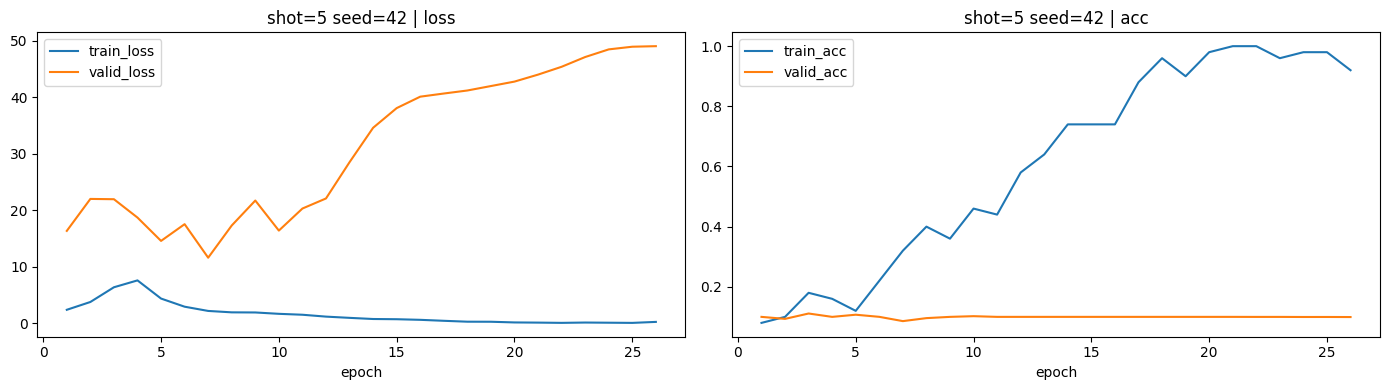

In [16]:

def plot_history(history_df, title='Training history'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train_loss')
    axes[0].plot(history_df['epoch'], history_df['valid_loss'], label='valid_loss')
    axes[0].set_title(title + ' | loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['train_acc'], label='train_acc')
    axes[1].plot(history_df['epoch'], history_df['valid_acc'], label='valid_acc')
    axes[1].set_title(title + ' | acc')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# przykład:
plot_history(all_histories[(5, 42)], title='shot=5 seed=42')


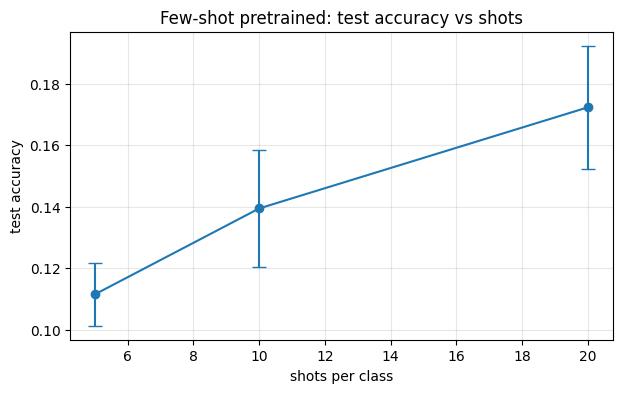

In [17]:

plt.figure(figsize=(7, 4))
plt.errorbar(
    agg_df['shot'],
    agg_df['test_acc_mean'],
    yerr=agg_df['test_acc_std'].fillna(0),
    marker='o',
    capsize=5,
)
plt.title('Few-shot pretrained: test accuracy vs shots')
plt.xlabel('shots per class')
plt.ylabel('test accuracy')
plt.grid(True, alpha=0.3)
plt.show()


In [30]:
def load_checkpoint_model(checkpoint_path: str, num_classes: int, cfg: dict):
    model = build_model_from_cfg(num_classes=num_classes, cfg=cfg)
    state = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(state['model'])
    model.to(DEVICE)
    model.eval()
    return model, state